In [6]:
# kpi(key performance indicator)
# used for summary explanation of data
import pandas as pd
import matplotlib.pyplot as plt #for data visualization 
import seaborn as sns# for visulatixation -> advance package than matplotlib

In [7]:
df=pd.read_csv('Data\pizza_sales.csv')
df.head(3)

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\dell\AppData\Local\Temp\ipykernel_16872\1019750309.py:1: SyntaxWarning: invalid escape sequence '\p'
  df=pd.read_csv('Data\pizza_sales.csv')


,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza


In [8]:
df.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

In [9]:
unq_cat=df['pizza_category'].unique()
unq_size=df['pizza_size'].unique()
print("unique pizza category:",unq_cat)
print("unique pizza size:",unq_size)    

unique pizza category: ['Classic' 'Veggie' 'Supreme' 'Chicken']
unique pizza size: ['M' 'L' 'S' 'XL' 'XXL']


In [12]:
# feature engineering
# convert object type of order_date to and order_time datetime type
df['order_date']=pd.to_datetime(df['order_date'], format="mixed")
df['order_time']=pd.to_datetime(df['order_time'],format="%H:%M:%S")

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   pizza_id           48620 non-null  int64         
 1   order_id           48620 non-null  int64         
 2   pizza_name_id      48620 non-null  object        
 3   quantity           48620 non-null  int64         
 4   order_date         48620 non-null  datetime64[ns]
 5   order_time         48620 non-null  datetime64[ns]
 6   unit_price         48620 non-null  float64       
 7   total_price        48620 non-null  float64       
 8   pizza_size         48620 non-null  object        
 9   pizza_category     48620 non-null  object        
 10  pizza_ingredients  48620 non-null  object        
 11  pizza_name         48620 non-null  object        
dtypes: datetime64[ns](2), float64(2), int64(3), object(5)
memory usage: 4.5+ MB


In [18]:
# extract day, month, year from order_date and hour from order_time column
df['order_day'] = df['order_date'].dt.month_name()# extarct month name
df['order_month'] = df['order_date'].dt.day_name()# extract day name
df['order_hour'] = df['order_time'].dt.hour# extract hour
df.head(3)

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,order_day,order_month,order_year,order_hour
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,January,Thursday,0,11
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,January,Thursday,0,11
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,January,Thursday,0,11


In [ ]:
# after feautre scaling we can do daata analysis and visualtization to get insight from data
# first we need to extrax 

In [ ]:
#sum of total_price
total_revenue = df['total_price'].sum()
total_pizzas_sold = df['quantity'].sum()

#count of unique order id
unique_orders = df['order_id'].nunique()
#average order value(AOV)= total revenue/number of unique orders
average_order_value = total_revenue/unique_orders
#average price per pizza = total pizzas sold/ total orders
average_price_per_pizza = total_pizzas_sold/unique_orders
print("Total Revenue: ",round(total_revenue, 2))
print("Total Pizzas Sold: ",total_pizzas_sold)
print("Unique Orders: ",unique_orders)
print("Average Order Value: ",round(average_order_value, 2))
print("Average Price Per Pizza: ",round(average_price_per_pizza, 2))

Total Revenue:  817860.05
Total Pizzas Sold:  49574
Unique Orders:  21350
Average Order Value:  38.31
Average Price Per Pizza:  2.32


In [22]:
# data analysis and visualization
# daILY  TREND
# a line bar chart showing sales by day of the week
# useful for staffing and operation planning
df['order_day'].unique()


array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype=object)

In [24]:
day_sales=df.groupby('order_day')['total_price'].sum().reset_index()
day_sales

,order_day,total_price
0,April,70312.00
1,August,69497.30
2,December,61058.10
3,February,64419.45
4,January,71620.15
5,July,70880.65
6,June,68161.45
7,March,71301.40
8,May,67648.80
9,November,71004.85


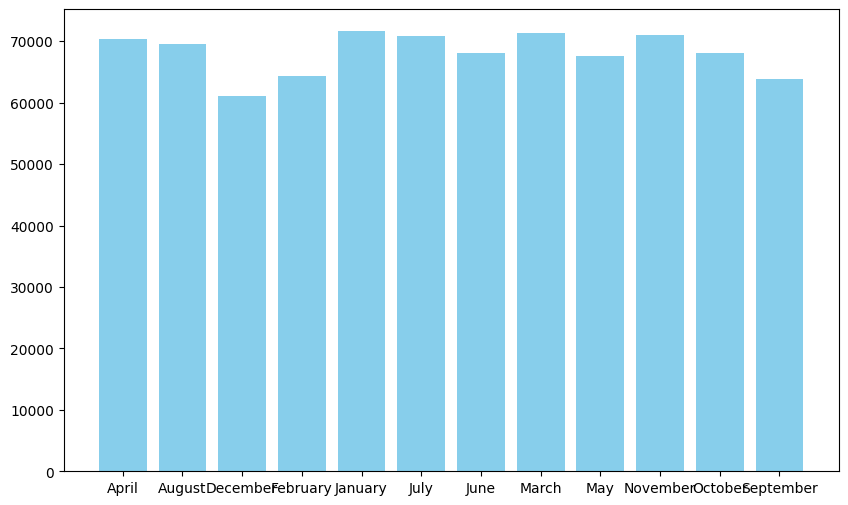

In [27]:
# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(day_sales['order_day'], day_sales['total_price'], color='skyblue')
plt.show()